# WiBD Global Datathon 2026 - Wildfire Threat Prediction Datathon

**Research Questions**:
1) Which fires will reach populated areas?  
2) How quickly will they get there?  
3) Which communities should prepare first?  

**The Task**
Build a *survival model* using only the earliest available signals: the 5 hours after ignition.

**Core Challenge**: predict the probability that a wildfire will threaten an evacuation zone within 12,24,48 and 72 hours, based purely on data from the first 5 hours post-ignition(t0 to t0+5h)  

**Event Definition**
**event=1** fire hits within 72h window -> time_to_hit_hours = observed time from t0+5h  
**event=0** fire does not hit eithin 72h

**The Outcome**
Two outcomes need to be deliver simultaneously:
| **Outcome**        | **Description**                                                                 |
|--------------------|---------------------------------------------------------------------------------|
| Urgency ranking    | Identifies which fires require immediate attention                              |
| Calibrated Prob    | Provides risk estimates responders can trust for threshold‑based decisions      |

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/sample_submission.csv
/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/train.csv
/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/metaData.csv
/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/test.csv


**Analytical Pipeline**:


1.   Raw Data (train/test)
2.   Data Understanding: verify integrity, targets vs features
3.   EDA: target distribution, feature-target relationship, multicollinearity, Kaplan-Meier survival curves
4.   Data Cleaning: drop almost perfect correlated feature variables
5.   Feature Engineering
6.   Modelling: Random Survival Forest
7.   Evaluation: C-index, Brier score and final Hybrid Score
8.   Submission: P(hit by 12h, 24h, 48h, 72h) per fire





## 0. Setup & Imports

In [2]:
# Install survival analysis library: lifelines: survival-analysis toolkit
!pip install lifelines --quiet

# Core libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#import lifelines
from lifelines import KaplanMeierFitter

print("Libraries imported successfully!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.6 MB/s eta 0:00:00
Libraries imported successfully!


In [3]:
# Importing libraries for modeling section
!pip install scikit-survival --quiet

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, brier_score
from sklearn.model_selection import StratifiedKFold

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 6.9 MB/s eta 0:00:00
Libraries imported successfully!


In [4]:
# Load datasets:
# metadata: column-level data dictionary (category labels per feature)
# train: labelled fires (event + time_to_hit_hours)
# test: unlabelled fires to score for the submission
metadata = pd.read_csv("/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/metaData.csv")
train_original = pd.read_csv("/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/train.csv")
test_original = pd.read_csv("/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/test.csv")

# Work on copies so originals remain intact for reference or re-runs: all transformation are applied to working copies
train=train_original.copy()
test=test_original.copy()

print(f'Datasets loaded successfully!')

# Dataset dimensions
print(f'{train.shape[0]} rows in the training dataset and {train.shape[1]} columns.')
print(f'{test.shape[0]} rows in the training dataset and {test.shape[1]} columns.')

Datasets loaded successfully!
221 rows in the training dataset and 37 columns.
95 rows in the training dataset and 35 columns.


## 1. Data Understanding
We need to establish three things:
1) What does the data look like in terms of column types, summary stats?
2) Is it clean? Missing values, duplicates, train/test alignment?
3) How are features organized?

In [5]:
# Preview the first rows of the training set
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [6]:
# List all column names
print("Train dataset columns:", train.columns)

# Identify the target variable and the features
feature_cols = [col for col in train.columns if col not in ['event_id', 'time_to_hit_hours', 'event']]
print(len(feature_cols), "feature columns identified:", feature_cols)

Train dataset columns: Index(['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h',
       'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h',
       'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first',
       'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h',
       'radial_growth_m', 'radial_growth_rate_m_per_h',
       'centroid_displacement_m', 'centroid_speed_m_per_h',
       'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos',
       'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h',
       'dist_slope_ci_0_5h', 'closing_speed_m_per_h',
       'closing_speed_abs_m_per_h', 'projected_advance_m',
       'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos',
       'alignment_abs', 'cross_track_component', 'along_track_speed',
       'event_start_hour', 'event_start_dayofweek', 'event_start_month',
       'time_to_hit_hours', 'event'],
      dtype='object')
34 feature columns identified: ['num_peri

In [7]:
# Verify all feature columns are present in the test set
# Are all these training columns present in the testing set?
missing_cols = [col for col in feature_cols if col not in test.columns]
if missing_cols:
    print("Warning: The following feature columns are missing in the test set:", missing_cols)
else:
    print("All feature columns are present in the test set.")

All feature columns are present in the test set.


In [8]:
# Check for missing values
# Checking for missing values in the training set
missing_values_train = train.isnull().sum()
print(f"Missing values in the training set:{missing_values_train.sum()}")

# Checking for missing values in the testing set
missing_values_test = test.isnull().sum()
print(f"Missing values in the testing set:{missing_values_test.sum()}")

Missing values in the training set:0
Missing values in the testing set:0


In [9]:
# Verify event_id uniqueness and train/test overlap
# The event_id is the identifier for each event: how many unique events are there in the training set and in the test set?
unique_events_train=train["event_id"].unique()
print(f'There are {len(unique_events_train)} events in the training set.')

# How many unique events are there in the test set?
unique_events_test=test["event_id"].unique()
print(f'There are {len(unique_events_test)} events in the test set.')

# Are there event_ids in the test set that are not in the training set?
unique_events_test_not_in_train=[event for event in unique_events_test if event not in unique_events_train]
print(f'There are {len(unique_events_test_not_in_train)} events that are in the testing set but not in the training set.')
if len(unique_events_test_not_in_train)==95:
    print("All events in the test set are not in the training set, which is expected.")

There are 221 events in the training set.
There are 95 events in the test set.
There are 95 events that are in the testing set but not in the training set.
All events in the test set are not in the training set, which is expected.


In [10]:
# Explore the metadata
print(metadata["category"].unique())

['identifier' 'target' 'temporal_coverage' 'growth' 'centroid_kinematics'
 'distance' 'directionality' 'temporal_metadata']


In [11]:
# For each main category, create a list containing all variables that belong to that category
categories=metadata["category"].unique()
for category, group in metadata.groupby("category"):
    globals()[category] = group["column"].tolist()


print(f'Temporal metadata features:{temporal_metadata}')
print(f'Temporal coverage:{temporal_coverage}')
print(f'Fire growth features:{growth}')
print(f'Centroid features:{centroid_kinematics}')
print(f'Distance features:{distance}')
print(f'Directionality features:{directionality}')


Temporal metadata features:['event_start_hour', 'event_start_dayofweek', 'event_start_month']
Temporal coverage:['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h']
Fire growth features:['area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h']
Centroid features:['centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos']
Distance features:['dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h']
Directionality features:['alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed']


In [12]:
# Summary statistics for all columns for training set
train.describe()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
count,2.210000e+02,221.000000,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000,221.000000,...,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000
mean,5.384397e+07,2.063348,0.979869,0.728507,619.131641,26.332398,1.789087e-01,6.167128,4.683276,0.389346,...,0.046000,-0.004971,0.172704,1.617188,0.551690,15.429864,2.841629,6.782805,37.567626,0.312217
std,2.507456e+07,2.578859,1.738052,0.445739,1447.723668,187.437018,1.302001e+00,40.467370,2.083529,1.340348,...,0.171690,0.371909,0.329210,37.789199,46.760648,7.921250,1.974217,1.571876,25.902361,0.464450
min,1.089246e+07,1.000000,0.000000,0.000000,0.037525,-0.000022,-1.437844e-07,-0.000005,0.036838,0.000000,...,0.000000,-0.999995,0.000000,-213.411731,-526.597241,0.000000,0.000000,1.000000,0.001220,0.000000
25%,3.209326e+07,1.000000,0.000000,0.000000,25.219058,0.000000,0.000000e+00,0.000000,3.266487,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,6.000000,12.242322,0.000000
50%,5.244094e+07,1.000000,0.000000,1.000000,110.149250,0.000000,0.000000e+00,0.000000,4.710874,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,3.000000,7.000000,43.109830,0.000000
75%,7.457274e+07,2.000000,1.356107,1.000000,485.092561,0.000000,0.000000e+00,0.000000,6.186399,0.000000,...,0.000000,0.000000,0.071697,0.000000,0.000000,21.000000,5.000000,8.000000,63.938706,1.000000
max,9.933973e+07,17.000000,4.994457,1.000000,11942.392115,2508.041442,1.788970e+01,520.443033,9.387933,7.827656,...,0.917415,0.994594,0.999995,277.110446,383.099186,23.000000,6.000000,9.000000,66.994474,1.000000


**Data Understanding - Findings:**
- *no missing values* detected in either train or test so no imputation required
- *no event_id overlap* between train and test data so no leakage
- target columns are present only in train, as expected and all *feature columns are aligned between train and test data*
- summary stats reveal several features with extreme skew (need for log-transformed variants or encoding)

## 2. Exploratory Data analysis (EDA)

### 2a. Target Variable Analysis

In [13]:
# Partition into hit fires (event=1) and censored fires (event=0)
hit = train[train["event"]==1]
censored = train[train["event"]==0]

print(f'Hit fires: {len(hit)} events, median time-to-hit: {round(hit.time_to_hit_hours.median())}h')
print(f'Censored: {len(censored)} events, median observed time: {round(censored.time_to_hit_hours.median())}h')

Hit fires: 69 events, median time-to-hit: 4h
Censored: 152 events, median observed time: 61h


Distribution of the target variable 'event': event
0    152
1     69
Name: count, dtype: int64


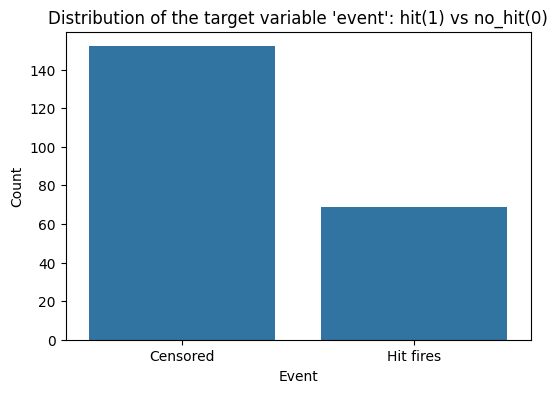

In [14]:
# Class balance: look at the distribution of the target variable "event"

print("Distribution of the target variable 'event':", train["event"].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x="event", data=train)
plt.title("Distribution of the target variable 'event': hit(1) vs no_hit(0)")
plt.xlabel("Event")
plt.ylabel("Count")
plt.xticks([0,1],["Censored","Hit fires"])
plt.show()

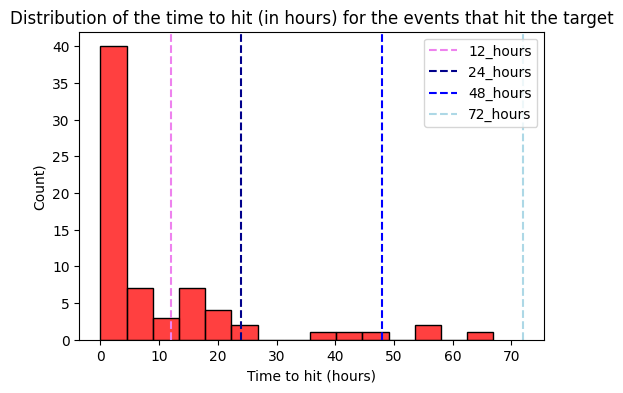

In [15]:
# Time-to-hit distribution for fires that actually hit (event=1)
plt.figure(figsize=(6,4))
sns.histplot(train[train["event"]==1]["time_to_hit_hours"], bins=15, color='red')
plt.axvline(12, color="violet", linestyle="--", label="12_hours")
plt.axvline(24, color="darkblue", linestyle="--", label="24_hours")
plt.axvline(48, color="blue", linestyle="--", label="48_hours")
plt.axvline(72, color="lightblue", linestyle="--", label="72_hours")
plt.title("Distribution of the time to hit (in hours) for the events that hit the target")
plt.xlabel("Time to hit (hours)")
plt.ylabel("Count)")
plt.legend(loc="upper right")
plt.show()

**Target Analysis - Findings:**
- *class imbalance* is present (be careful when running performance analysis)
- *median_time_to_hit* for event=1 is short (4h) suggesting that the fires threatening evacuation zones tend to do so quickly

### 2b. Feature Distributions
We examine two temporal metadata features, ignition hour and month, split across hit fires censored fires and the full training set.

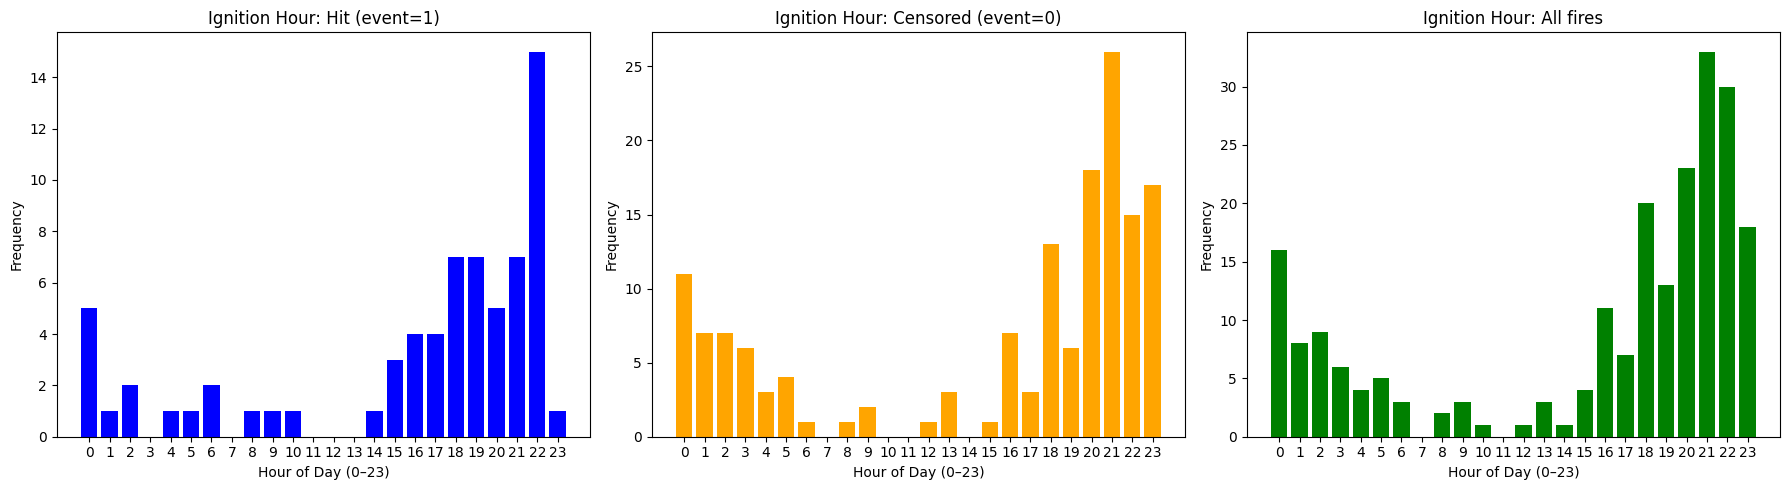

In [16]:
# Fire start hour distribution: compare hourly ignition patterns across hit fires, censored fires, and all fires.
hour_counts = {
    "Hit (event=1)": hit["event_start_hour"].value_counts().sort_index(),
    "Censored (event=0)": censored["event_start_hour"].value_counts().sort_index(),
    "All fires": train["event_start_hour"].value_counts().sort_index(),
}

colors = ["blue", "orange", "green"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, (title, counts), color in zip(axes, hour_counts.items(), colors):
    ax.bar(counts.index, counts.values, color=color)
    ax.set_title(f"Ignition Hour: {title}")
    ax.set_xlabel("Hour of Day (0–23)")
    ax.set_ylabel("Frequency")
    ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

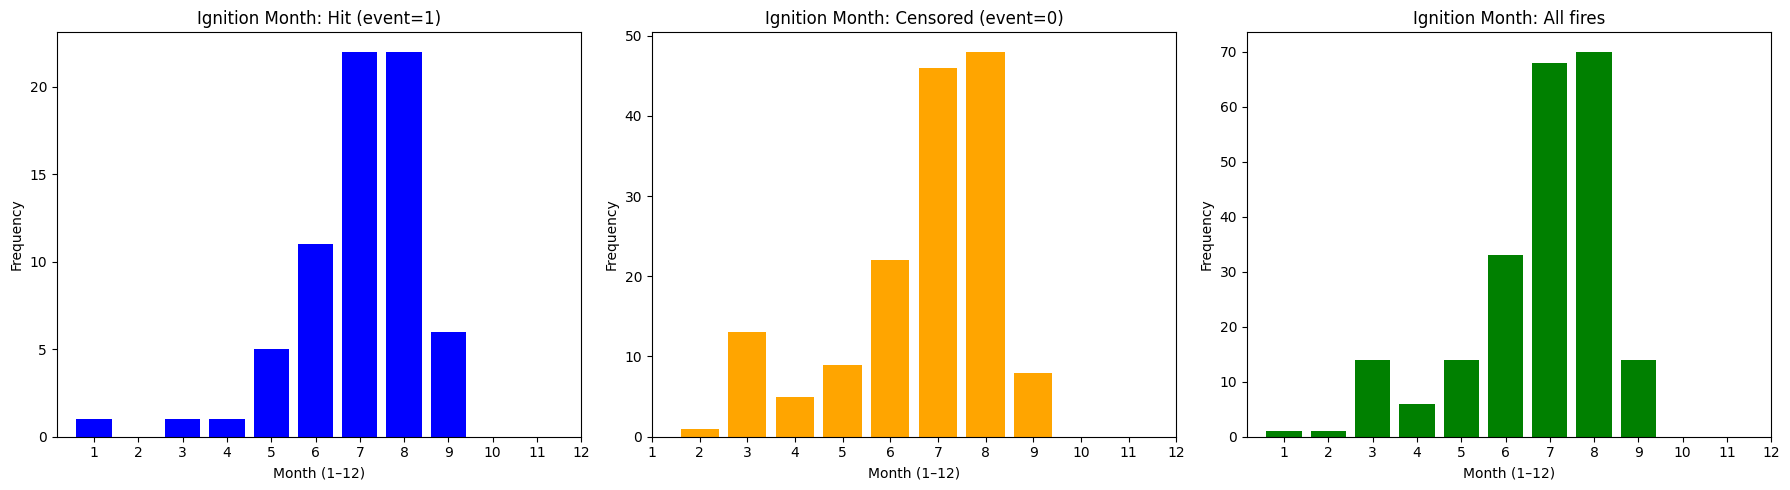

In [17]:
# Fire start month distribution
# Seasonal patterns may differ between fires that threaten communities vs. those that don't.
month_counts = {
    "Hit (event=1)": hit["event_start_month"].value_counts().sort_index(),
    "Censored (event=0)": censored["event_start_month"].value_counts().sort_index(),
    "All fires": train["event_start_month"].value_counts().sort_index(),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, (title, counts), color in zip(axes, month_counts.items(), colors):
    ax.bar(counts.index, counts.values, color=color)
    ax.set_title(f"Ignition Month: {title}")
    ax.set_xlabel("Month (1–12)")
    ax.set_ylabel("Frequency")
    ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()


In [18]:
# Skeweness
# NOTE: log-transformed variant already exist for several features in this dataset, prefer those over applying a second log transform to raw values
skewness = train[feature_cols].skew().abs().sort_values(ascending=False)
print(f"Features with |skew| > 10 : {list(skewness[skewness > 10].index)}")
print(f"Features with |skew| ≤ 10 : {list(skewness[(skewness > 5) & (skewness <= 10)].index)}")
print(f"Features with |skew| ≤  5 : {list(skewness[skewness <= 5].index)}")


Features with |skew| > 10 : ['dist_slope_ci_0_5h', 'area_growth_rel_0_5h', 'relative_growth_0_5h', 'dist_std_ci_0_5h', 'area_growth_abs_0_5h', 'dist_change_ci_0_5h', 'projected_advance_m', 'closing_speed_abs_m_per_h', 'closing_speed_m_per_h', 'area_growth_rate_ha_per_h']
Features with |skew| ≤ 10 : ['dist_accel_m_per_h2', 'centroid_speed_m_per_h', 'centroid_displacement_m', 'radial_growth_rate_m_per_h', 'radial_growth_m', 'log_area_ratio_0_5h']
Features with |skew| ≤  5 : ['area_first_ha', 'spread_bearing_deg', 'dist_fit_r2_0_5h', 'along_track_speed', 'log1p_growth', 'spread_bearing_cos', 'num_perimeters_0_5h', 'cross_track_component', 'dist_min_ci_0_5h', 'alignment_abs', 'dt_first_last_0_5h', 'spread_bearing_sin', 'event_start_month', 'low_temporal_resolution_0_5h', 'event_start_hour', 'event_start_dayofweek', 'log1p_area_first', 'alignment_cos']


In [19]:
# Temporal resolution quality flag
# These are fires with multiple perimeter observations: growth/movement features are meaningful here
# low_temporal_resolution_0_5h = 0 → fire had multiple perimeter observations (growth / movement features are reliable)
# low_temporal_resolution_0_5h = 1 → only a single observation; derived features (e.g. area_growth) are unreliable / zero-inflated
train[train["low_temporal_resolution_0_5h"]==1]

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
3,12044083,1,0.0,1,67.631125,0.0,0.0,0.0,4.228746,0.0,...,0.0,0.0,0.0,0.0,0.0,20,5,8,60.953021,0
5,12773599,1,0.0,1,184.767610,0.0,0.0,0.0,5.224496,0.0,...,0.0,0.0,0.0,0.0,0.0,0,5,7,44.026384,0
6,13122360,1,0.0,1,119.364203,0.0,0.0,0.0,4.790522,0.0,...,0.0,0.0,0.0,0.0,0.0,21,1,3,14.845392,1
7,13745272,1,0.0,1,1388.283778,0.0,0.0,0.0,7.236544,0.0,...,0.0,0.0,0.0,0.0,0.0,16,0,6,66.767927,0
9,15743535,1,0.0,1,5.218524,0.0,0.0,0.0,1.827533,0.0,...,0.0,0.0,0.0,0.0,0.0,17,2,7,54.638109,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,96270286,1,0.0,1,3403.021842,0.0,0.0,0.0,8.132713,0.0,...,0.0,0.0,0.0,0.0,0.0,20,1,7,65.012587,0
215,96372213,1,0.0,1,169.688297,0.0,0.0,0.0,5.139839,0.0,...,0.0,0.0,0.0,0.0,0.0,21,0,6,43.109830,0
216,97075632,1,0.0,1,51.295195,0.0,0.0,0.0,3.956904,0.0,...,0.0,0.0,0.0,0.0,0.0,17,6,6,66.340624,0
219,99071478,1,0.0,1,20.223659,0.0,0.0,0.0,3.055117,0.0,...,0.0,0.0,0.0,0.0,0.0,15,0,8,22.975783,1


In [20]:
# isolating the low_temporal variable and event and time_to_hit variables
low_temp_df=train[["low_temporal_resolution_0_5h","event","time_to_hit_hours"]]
n_active=(low_temp_df["low_temporal_resolution_0_5h"]==0).sum()
n_poor=(low_temp_df["low_temporal_resolution_0_5h"]==1).sum()
print(f"Active (good quality) fires:{n_active}")
print(f"Poor temporal resolution:{n_poor}")

print(f'For hit event, active fires: {len(low_temp_df[(low_temp_df["low_temporal_resolution_0_5h"]==0) & (low_temp_df["event"]==1)])} out of {len(low_temp_df[(low_temp_df["event"]==1)])}')
print(f'For hit event, poor temporal resolution: {len(low_temp_df[(low_temp_df["low_temporal_resolution_0_5h"]==1) & (low_temp_df["event"]==1)])} out of {len(low_temp_df[(low_temp_df["event"]==1)])}')

print(f'For censored event, active fires: {len(low_temp_df[(low_temp_df["low_temporal_resolution_0_5h"]==0) & (low_temp_df["event"]==0)])} out of {len(low_temp_df[(low_temp_df["event"]==0)])}')
print(f'For censored event, poor temporal resolution: {len(low_temp_df[(low_temp_df["low_temporal_resolution_0_5h"]==1) & (low_temp_df["event"]==0)])} out of {len(low_temp_df[(low_temp_df["event"]==0)])}')



Active (good quality) fires:60
Poor temporal resolution:161
For hit event, active fires: 36 out of 69
For hit event, poor temporal resolution: 33 out of 69
For censored event, active fires: 24 out of 152
For censored event, poor temporal resolution: 128 out of 152


In [21]:
# Deep Dive: low_resolution = 1
low_quality_data=train[train["low_temporal_resolution_0_5h"]==1]
low_quality_data=low_quality_data[growth]
# Check the growth values
print(f'Mean area_growth_abs for poor-quality fires: {low_quality_data["area_growth_abs_0_5h"].mean():.4f}')

Mean area_growth_abs for poor-quality fires: 0.0000


**Feature Distributions - Findings:**
- *ignition hour* has no dominant peak and only looking at it along it may not be strong as a single predictor
- *ignition month* month alone is not a discriminat for both groups but maybe a fire_season flag may be interesting to try
- regarding *skewness* several features present extreme right skew, mainly growth and distance columns - preference to log-transformed variable
- *Temporal resolution flag* when = 1 it means that for these fires all growth features haven't been tracked or are unreliable

### 2c. Feature and Target Variables relationships
This section will identify which feature are most predictive of whether the fire hits and how quickly it hits.

In [22]:
# Correlation of each feature with the event indicator
print(f'Correlation between features and event: higher absolute value -> stronger prediction power')
corr_feature_event = train[feature_cols + ['event']].corr()['event'].drop('event').abs().sort_values(ascending=False)
print(corr_feature_event.head(15))


Correlation between features and event: higher absolute value -> stronger prediction power
dist_min_ci_0_5h                0.481379
low_temporal_resolution_0_5h    0.379117
num_perimeters_0_5h             0.370501
dt_first_last_0_5h              0.352954
alignment_abs                   0.349115
spread_bearing_cos              0.323189
log1p_growth                    0.292688
spread_bearing_deg              0.281012
log_area_ratio_0_5h             0.229327
radial_growth_rate_m_per_h      0.214956
radial_growth_m                 0.209343
centroid_speed_m_per_h          0.209254
centroid_displacement_m         0.207992
spread_bearing_sin              0.188252
area_first_ha                   0.181334
Name: event, dtype: float64


In [23]:
# Correlation between features and time_to_hit_hours and event=1
print(f'Correlation between features and time_to_hit_hours and event=1')
corr_time = hit[feature_cols + ['time_to_hit_hours']].corr()['time_to_hit_hours'].drop('time_to_hit_hours').abs().sort_values(ascending=False)
print(corr_time.head(15))

Correlation between features and time_to_hit_hours and event=1
low_temporal_resolution_0_5h    0.457559
dt_first_last_0_5h              0.442325
alignment_abs                   0.367939
num_perimeters_0_5h             0.356114
spread_bearing_cos              0.304056
log1p_growth                    0.281972
spread_bearing_deg              0.276209
log1p_area_first                0.238842
dist_fit_r2_0_5h                0.227159
log_area_ratio_0_5h             0.188891
radial_growth_m                 0.185631
radial_growth_rate_m_per_h      0.184782
centroid_displacement_m         0.184089
centroid_speed_m_per_h          0.181409
spread_bearing_sin              0.176375
Name: time_to_hit_hours, dtype: float64


In [24]:
# Deep dive: dist_min_ci_0_5h (minimum distance to nearest evac zone in meters)
# This is the single strongest predictor — explore its relationship with event
# Bin dist_min_ci_0_5h into quartiles to see event rate per distance band
train['bins'] = pd.qcut(train['dist_min_ci_0_5h'], q=4)
print(train.groupby('bins')['event'].value_counts(normalize=True).rename("rate").round(3))

bins                      event
(306.954, 2965.218]       1        1.000
                          0        0.000
(2965.218, 31758.581]     0        0.764
                          1        0.236
(31758.581, 200228.864]   0        1.000
                          1        0.000
(200228.864, 757700.487]  0        1.000
                          1        0.000
Name: rate, dtype: float64


/tmp/ipykernel_16/2432598679.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(train.groupby('bins')['event'].value_counts(normalize=True).rename("rate").round(3))


In [25]:
# Verify potential overlap between max hit-distance and min-censored distance
print(f'Max value "dist_min_ci_0_5h" for event=1: {round(hit["dist_min_ci_0_5h"].max())}')
print(f'Min value "dist_min_ci_0_5h" for event=0: {round(censored["dist_min_ci_0_5h"].min())}')
if round(hit["dist_min_ci_0_5h"].max()) < round(censored["dist_min_ci_0_5h"].min()):
    print(f'No overlap')
else:
    print(f' Overlap!!')


Max value "dist_min_ci_0_5h" for event=1: 4674
Min value "dist_min_ci_0_5h" for event=0: 5216
No overlap


In [26]:
# All unique time_to_hit_hours values sorted — inspect the raw time distribution
print(f'Min value for time_to_hit_hours: {hit["time_to_hit_hours"].drop_duplicates().sort_values().min()} for hit event')
print(f'Max value for time_to_hit_hours: {hit["time_to_hit_hours"].drop_duplicates().sort_values().max()} for hit event')

print(f'Min value for time_to_hit_hours: {censored["time_to_hit_hours"].drop_duplicates().sort_values().min()} for censored event')
print(f'Max value for time_to_hit_hours: {censored["time_to_hit_hours"].drop_duplicates().sort_values().max()} for censored event')

Min value for time_to_hit_hours: 0.0012202119444444 for hit event
Max value for time_to_hit_hours: 66.92046277222222 for hit event
Min value for time_to_hit_hours: 0.3744860833333333 for censored event
Max value for time_to_hit_hours: 66.99447413277778 for censored event


In [27]:
# Descriptive statistics for hit fires only
hit.describe()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
count,6.900000e+01,69.000000,69.000000,69.000000,69.000000,69.000000,6.900000e+01,69.000000,69.000000,69.000000,...,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.0
mean,5.181321e+07,3.478261,1.888304,0.478261,230.374700,70.278843,4.989217e-01,16.499391,4.165201,0.970291,...,0.082383,0.061081,0.342901,-1.644560,1.115847,15.985507,2.492754,7.000000,9.969870,1.0
std,2.596803e+07,3.763637,2.024776,0.503187,419.054380,322.952709,2.273453e+00,69.472949,1.752577,1.995421,...,0.215050,0.516432,0.388816,57.112523,83.196298,7.130079,1.967554,1.424574,14.528462,0.0
min,1.175716e+07,1.000000,0.000000,0.000000,0.346640,-0.000022,-1.437844e-07,-0.000005,0.297613,0.000000,...,0.000000,-0.963147,0.000000,-213.411731,-526.597241,0.000000,0.000000,1.000000,0.001220,1.0
25%,2.576666e+07,1.000000,0.000000,0.000000,17.772251,0.000000,0.000000e+00,0.000000,2.932380,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,1.000000,6.000000,0.888895,1.0
50%,5.460626e+07,2.000000,1.169918,0.000000,58.197413,0.000000,0.000000e+00,0.000000,4.080878,0.000000,...,0.000000,0.000000,0.071697,0.000000,0.000000,19.000000,2.000000,7.000000,3.534846,1.0
75%,6.993899e+07,5.000000,4.088956,1.000000,200.386653,0.000000,0.000000e+00,0.000000,5.305227,0.000000,...,0.000000,0.326959,0.739068,0.000000,0.000000,21.000000,4.000000,8.000000,14.323375,1.0
max,9.907148e+07,17.000000,4.994457,1.000000,1951.613874,2508.041442,1.788970e+01,520.443033,7.576924,7.827656,...,0.917386,0.994594,0.994594,277.110446,383.099186,23.000000,6.000000,9.000000,66.920463,1.0


In [28]:
# Hit vs Censored: mean and median feature comparison
# Mean is sensitive to outliers; median provides a complementary robust view.


comparison = pd.DataFrame({
    'hit': hit[feature_cols].mean(),
    "censored" : censored[feature_cols].mean(),
})
comparison["difference"]=comparison['hit']-comparison['censored']
comparison["absolute difference"]=comparison["difference"].abs()
print(f'Mean comparison (sorted by absolute difference):')
display(comparison.sort_values(by="absolute difference", ascending=False))

comparison_median = pd.DataFrame({
    'hit': hit[feature_cols].median(),
    "censored" : censored[feature_cols].median(),
})
comparison_median["difference"]=comparison_median['hit']-comparison_median['censored']
comparison_median["absolute difference"]=comparison_median["difference"].abs()
print(f'Median comparison (sorted by absolute difference):')
display(comparison_median.sort_values(by="absolute difference", ascending=False))



Mean comparison (sorted by absolute difference):


,hit,censored,difference,absolute difference
dist_min_ci_0_5h,2285.818350,179832.303100,-177546.484750,177546.484750
area_first_ha,230.374700,795.606831,-565.232132,565.232132
centroid_displacement_m,111.657143,13.691235,97.965908,97.965908
radial_growth_m,74.343170,9.041167,65.302003,65.302003
area_growth_abs_0_5h,70.278843,6.383025,63.895818,63.895818
dist_change_ci_0_5h,-30.567153,-1.080813,-29.486340,29.486340
projected_advance_m,30.567153,1.080813,29.486340,29.486340
spread_bearing_deg,33.206949,4.949425,28.257525,28.257525
centroid_speed_m_per_h,30.217648,3.662570,26.555078,26.555078
dist_std_ci_0_5h,21.362137,2.049187,19.312950,19.312950


Median comparison (sorted by absolute difference):


,hit,censored,difference,absolute difference
dist_min_ci_0_5h,2429.801581,128842.069272,-126412.267691,126412.267691
area_first_ha,58.197413,162.424790,-104.227377,104.227377
dt_first_last_0_5h,1.169918,0.000000,1.169918,1.169918
log1p_area_first,4.080878,5.096079,-1.015202,1.015202
num_perimeters_0_5h,2.000000,1.000000,1.000000,1.000000
low_temporal_resolution_0_5h,0.000000,1.000000,-1.000000,1.000000
event_start_dayofweek,2.000000,3.000000,-1.000000,1.000000
event_start_hour,19.000000,19.500000,-0.500000,0.500000
alignment_abs,0.071697,0.000000,0.071697,0.071697
area_growth_abs_0_5h,0.000000,0.000000,0.000000,0.000000


**Features and Target Variables - Findings:**
- *dist_min_ci_0_5h*: --> Median for HIT: 2.4km |  Median for CENSORED: 129km | Dominant signal: should be included in every model
- *area_first_ha*: --> Median for HIT: 58ha |  Median for CENSORED: 162ha
- the bottom of the median table shows the 0 median issue that we have studied later: for instance the area growth has a median of 0 in both groups. That feature appears useless in the median analysis but for the same variable in the mean analysis it actually appears meaningful (but influenced by the outliers)




### 2d. Inter-feature relationships
Check for multicollinearity: features that are near-perfectly correlated carry redundant information and should not both be included in the model. We flag pairs with |corr| ≥ 0.9 as candidates for removal.

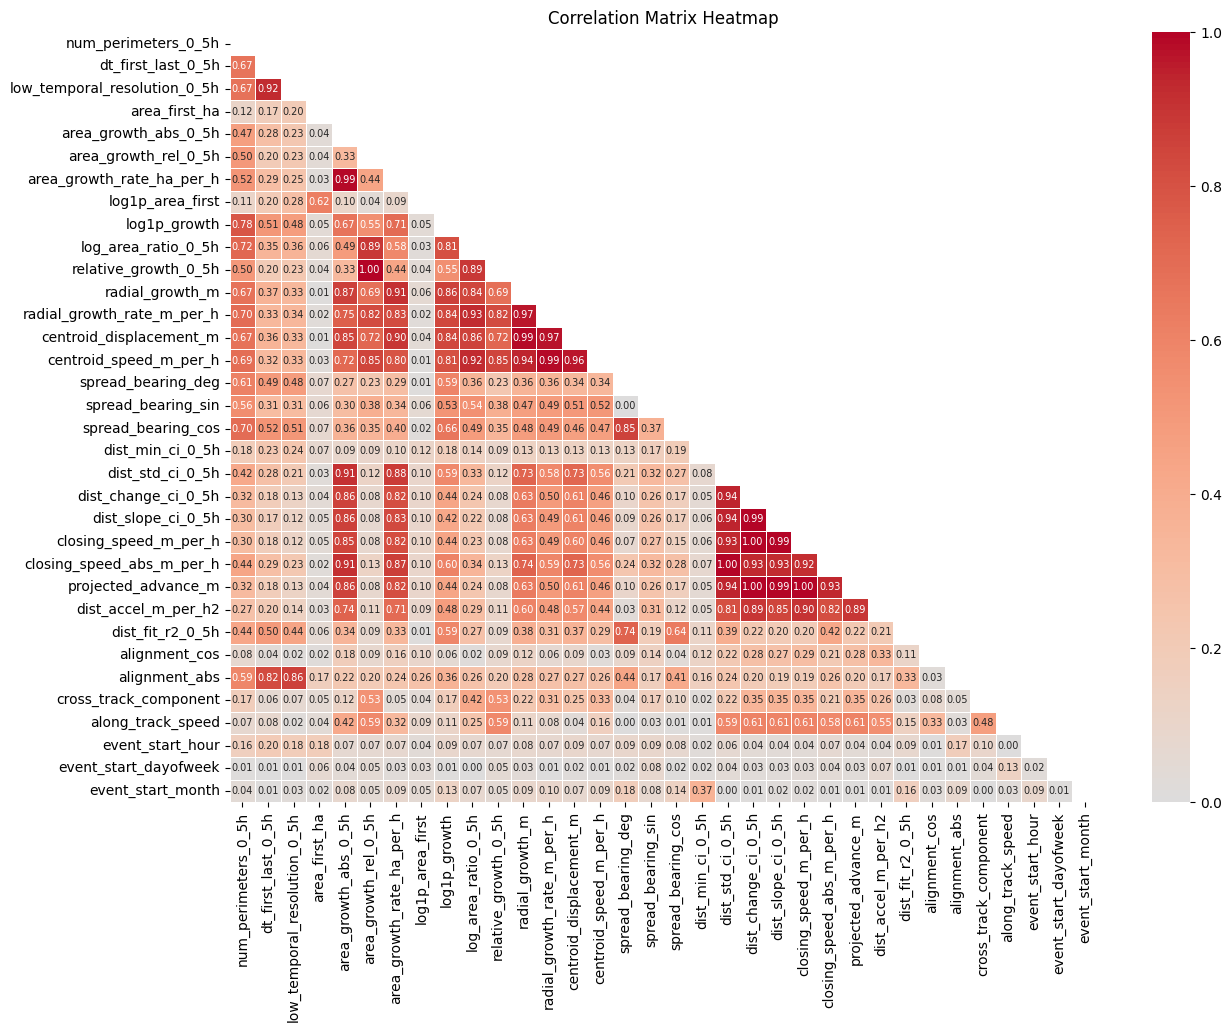

In [29]:
# Correlation heatmap
matrix=train[feature_cols].corr().abs()
mask = np.triu(np.ones_like(matrix, dtype=bool)) # create a mask for the upper triangle for a readable matrix
plt.figure(figsize=(14,10))
sns.heatmap(matrix,mask=mask, annot=True, cmap='coolwarm', fmt='.2f', center=0, linewidths=0.5,vmin=0, vmax=1, annot_kws={"size": 7})
plt.title("Correlation Matrix Heatmap")
plt.show()


In [30]:
# Since the map is too confusioned let's identify clearely which attributes have a >0.9 correlation
upper_tri=matrix.where(np.triu(np.ones(matrix.shape),k=1).astype(bool))

# stack the matrix into a Series and filter for >=0.9
high_corr_pairs=upper_tri.stack().sort_values(ascending=False)
strong_rel=high_corr_pairs[high_corr_pairs.abs() >=0.9]

print(f'High correlation pairs: {strong_rel}')

High correlation pairs: dist_change_ci_0_5h         projected_advance_m             1.000000
area_growth_rel_0_5h        relative_growth_0_5h            1.000000
dist_change_ci_0_5h         closing_speed_m_per_h           0.998166
closing_speed_m_per_h       projected_advance_m             0.998166
dist_std_ci_0_5h            closing_speed_abs_m_per_h       0.996875
dist_slope_ci_0_5h          closing_speed_m_per_h           0.993135
                            projected_advance_m             0.993057
dist_change_ci_0_5h         dist_slope_ci_0_5h              0.993057
area_growth_abs_0_5h        area_growth_rate_ha_per_h       0.991339
radial_growth_m             centroid_displacement_m         0.989127
radial_growth_rate_m_per_h  centroid_speed_m_per_h          0.989008
                            centroid_displacement_m         0.969151
radial_growth_m             radial_growth_rate_m_per_h      0.966359
centroid_displacement_m     centroid_speed_m_per_h          0.962299
dist_std_c

**Inter Feature Relationships - Findings:**
- redundant feature pairs: the weaker member of each pair should be dropped

### 2e. Kaplan-Meier Survival Curves
The KM curve shows P(fire has NOT hit by time t), accounting for censoring. The curve accounts for the fact that censored fires were observed safely up to their last recorded time.



#### Global KM Curve
The overall survival function for the entire training set, with key submission horizons marked.

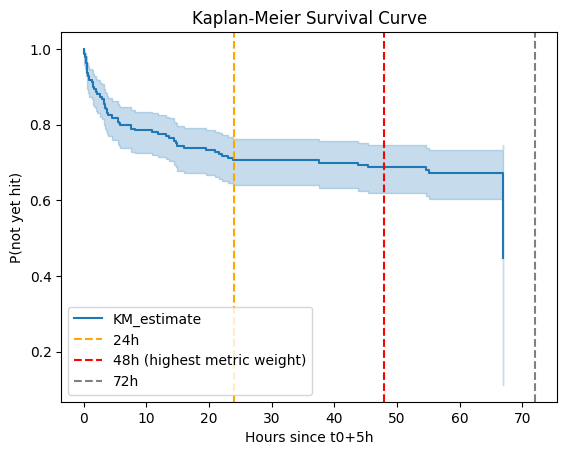

Cumulative hit probability at submission horizons: 
P(hit by 12h) = 0.225
P(hit by 24h) = 0.294
P(hit by 48h) = 0.313
P(hit by 72h) = 0.552


In [31]:
# Global Kaplan-Meier survival curve: P(fire has NOT hit by time t)
kmf=KaplanMeierFitter()
kmf.fit(train["time_to_hit_hours"], event_observed=train["event"])

kmf.plot()
plt.axvline(24, color='orange', linestyle='--', label='24h')
plt.axvline(48, color='red', linestyle='--', label='48h (highest metric weight)')
plt.axvline(72, color='gray', linestyle='--', label='72h')
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Hours since t0+5h')
plt.ylabel('P(not yet hit)')
plt.legend()
plt.show()

# Read off the three submission horizons
print("Cumulative hit probability at submission horizons: ")
for t in [12, 24, 48, 72]:
    s = kmf.survival_function_at_times([t]).values[0]
    print(f'P(hit by {t}h) = {1-s:.3f}')

**Global KM survival curve - Findings:**  
The curve is basically nearly flat between 24h and 60h, as almost no new fires hit during that window. The highest probability of a fire to hit is in the first 5/6 hours.

#### Stratified Kaplan-Meier curves

The global KM curve averages across all fires and hides important subgroup differences. Stratifying by the three features with the strongest separation (from the hit vs censored comparison above) reveals distinct survival regimes that the model needs to learn separately:

1. *dist_min_ci_0_5h* — distance quartiles
2. *low_temporal_resolution_0_5h* — data quality (binary)
3. *area_first_ha* — fire size (median split)

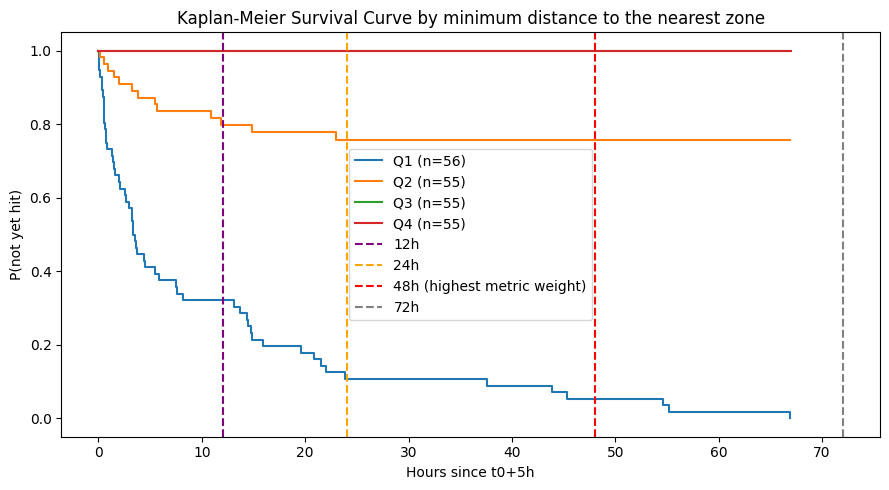

P(hit by t) per distance quartile:
Q1:[0.679, 0.893, 0.946, 1.0] (12h, 24h, 48h, 72h)
Q2:[0.201, 0.244, 0.244, 0.244] (12h, 24h, 48h, 72h)
Q3:[0.0, 0.0, 0.0, 0.0] (12h, 24h, 48h, 72h)
Q4:[0.0, 0.0, 0.0, 0.0] (12h, 24h, 48h, 72h)


In [32]:
# Stratified KM: distance quartiles (Q1=closest, Q4=most distant)
fig, ax=plt.subplots(figsize=(9,5))
train["dist_q"]=pd.qcut(train["dist_min_ci_0_5h"], q=4, labels=["Q1","Q2","Q3","Q4"])

for q in (["Q1","Q2","Q3","Q4"]):
    sub=train[train["dist_q"]==q]
    kmf=KaplanMeierFitter()
    kmf.fit(sub["time_to_hit_hours"],sub["event"], label=f"{q} (n={len(sub)})")
    kmf.plot_survival_function(ax=ax, ci_show=False)

plt.axvline(12, color='purple', linestyle='--', label='12h')
plt.axvline(24, color='orange', linestyle='--', label='24h')
plt.axvline(48, color='red', linestyle='--', label='48h (highest metric weight)')
plt.axvline(72, color='gray', linestyle='--', label='72h')
plt.title('Kaplan-Meier Survival Curve by minimum distance to the nearest zone')
plt.xlabel('Hours since t0+5h')
plt.ylabel('P(not yet hit)')
plt.legend()
plt.tight_layout()
plt.show()

# Read off the four submission horizons
print("P(hit by t) per distance quartile:")
for q in (["Q1","Q2","Q3","Q4"]):
    sub = train[train["dist_q"] == q]
    kmf=KaplanMeierFitter()
    kmf.fit(sub["time_to_hit_hours"],sub["event"])
    times=[12,24,48,72]
    vals=[round(float(1-kmf.survival_function_at_times(t).values[0]),3)
          for t in times]
    print(f'{q}:{vals} (12h, 24h, 48h, 72h)')

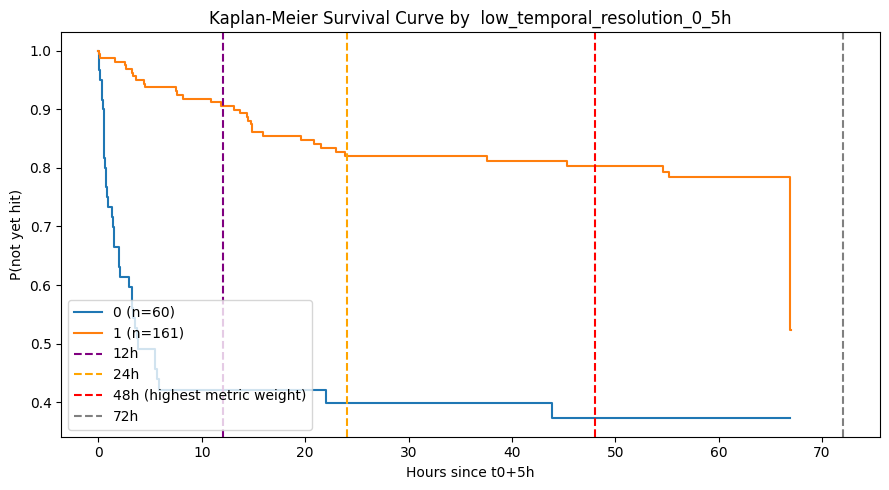

P(hit by t) by resolution quality:
active:[0.579, 0.601, 0.628, 0.628] (12h, 24h, 48h, 72h)
poor data:[0.094, 0.181, 0.197, 0.477] (12h, 24h, 48h, 72h)


In [33]:
# Stratified KM: temporal resolution quality (0=active, 1=poor data)
fig, ax=plt.subplots(figsize=(9,5))
for val, label in [(0,"active"),(1,"poor data")]:
    sub=train[train["low_temporal_resolution_0_5h"]==val]
    kmf=KaplanMeierFitter()
    kmf.fit(sub["time_to_hit_hours"],sub["event"], label=f"{val} (n={len(sub)})")
    kmf.plot_survival_function(ax=ax, ci_show=False)

plt.axvline(12, color='purple', linestyle='--', label='12h')
plt.axvline(24, color='orange', linestyle='--', label='24h')
plt.axvline(48, color='red', linestyle='--', label='48h (highest metric weight)')
plt.axvline(72, color='gray', linestyle='--', label='72h')
plt.title('Kaplan-Meier Survival Curve by  low_temporal_resolution_0_5h')
plt.xlabel('Hours since t0+5h')
plt.ylabel('P(not yet hit)')
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# Read off the four submission horizons
print("P(hit by t) by resolution quality:")
for val, label in [(0, "active"),(1,"poor data")]:
    sub=train[train["low_temporal_resolution_0_5h"]==val]
    kmf=KaplanMeierFitter()
    kmf.fit(sub["time_to_hit_hours"],sub["event"], label=f"{label} (n={len(sub)})")
    times=[12,24,48,72]
    vals=[round(float(1-kmf.survival_function_at_times(t).values[0]),3)
          for t in times]
    print(f'{label}:{vals} (12h, 24h, 48h, 72h)')

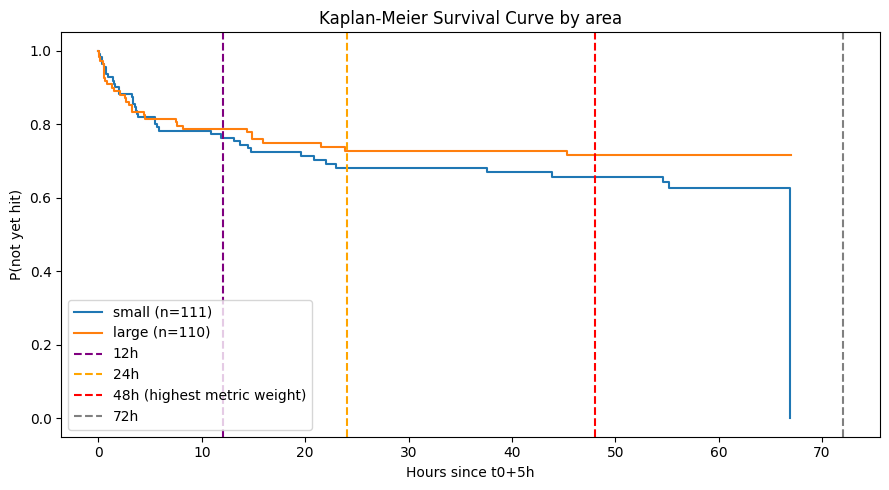

P(hit by t) by initial area group:
small:[0.236, 0.318, 0.343, 1.0] (12h, 24h, 48h, 72h)
large:[0.213, 0.272, 0.284, 0.284] (12h, 24h, 48h, 72h)


In [34]:
#Stratified KM: initial fire size (median split) (small = below-median area_first_ha, large=above median)
fig, ax=plt.subplots(figsize=(9,5))

median_area=train['area_first_ha'].median()
train["area_group"]= (train["area_first_ha"]> median_area).map({False:'small',True:'large'})

for label in ['small','large']:
    sub=train[train["area_group"]==label]
    kmf=KaplanMeierFitter()
    kmf.fit(sub["time_to_hit_hours"],sub["event"], label=f"{label} (n={len(sub)})")
    kmf.plot_survival_function(ax=ax, ci_show=False)

plt.axvline(12, color='purple', linestyle='--', label='12h')
plt.axvline(24, color='orange', linestyle='--', label='24h')
plt.axvline(48, color='red', linestyle='--', label='48h (highest metric weight)')
plt.axvline(72, color='gray', linestyle='--', label='72h')
plt.title('Kaplan-Meier Survival Curve by area')
plt.xlabel('Hours since t0+5h')
plt.ylabel('P(not yet hit)')
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# Read off the four submission horizons
print("P(hit by t) by initial area group:")
for label in ['small','large']:
    sub=train[train["area_group"]==label]
    kmf=KaplanMeierFitter()
    kmf.fit(sub["time_to_hit_hours"],sub["event"], label=f"{label} (n={len(sub)})")
    times=[12,24,48,72]
    vals=[round(float(1-kmf.survival_function_at_times(t).values[0]),3)
          for t in times]
    print(f'{label}:{vals} (12h, 24h, 48h, 72h)')

**Key findings from stratified KM curves:**

- **Distance creates four completely distinct survival regimes**: Q1 fires (closest, <8km) hit in 95% of cases by 48h. Q3 and Q4 fires (beyond 32km) never hit within the 72h window at any horizon.
- **Data quality doubles the hit probability**: active fires (low_res=0) hit at 63% by 48h vs 20% for poor-data fires (low_res=1). Note: the jump at 72h for poor-data fires is a censoring artifact, not real late hits.
- **Fire size alone is a weak stratifier**: small fires hit at 34% vs large at 28% by 48h — the difference is real but modest. Size is better used in combination with distance.

## 3. Data Cleaning

Remove one feature from each correlated pair identified in the previous section.

In [35]:
# Redundant feature pairs - to drop to avoid multicollinearity
# Criteria: prefer abs vs rate, displacement vs grath, speed over dist_change
redundant=["relative_growth_0_5h", # = area_growth_rel_0_5h (corr 1.00)
           "projected_advance_m", # = dist_change_ci_0_5h (corr 1.00)
           "area_growth_rate_ha_per_h",  # ≈ area_growth_abs_0_5h (corr 0.991)
           "radial_growth_m", # ≈ centroid_displacement_m (corr 0.989)
           "radial_growth_rate_m_per_h"] # ≈ centroid_speed_m_per_h (corr 0.989)
train=train.drop(columns=redundant)
test=test.drop(columns=redundant)

In [36]:
print(f'Train shape: {train.shape}, Test shape: {test.shape}')

Train shape: (221, 35), Test shape: (95, 30)


In [37]:
for col in train.columns:
    if col not in test.columns:
        print(col)

time_to_hit_hours
event
bins
dist_q
area_group


In [38]:
# Drop temporary columns created during the EDA: "bins", "dist_q", "area_group"
# were created for analysis only and must not enter the model
eda_cols=["bins", "dist_q", "area_group"]
train=train.drop(columns=eda_cols, errors="ignore")
print(f'Train shape: {train.shape}, Test shape: {test.shape}')

Train shape: (221, 32), Test shape: (95, 30)


## 4. Feature Engineering

This section collects actionable decisions after EDA

- check whether use log transformed variables especially for long skewed features  
- binary flag for zero-inflated features
- binary flag for dist_min_0_5h
- drop redundant variables (see correlation table) OKAY
- tree-based model do not need scaling (Cox-PH yes)


In [39]:
for df in[train, test]:
  df["fire_urgency"]=(df["num_perimeters_0_5h"])*(df["closing_speed_abs_m_per_h"])

In [40]:
for df in[train, test]:
  df["log_area_to_dist_ratio"]=np.log(df["area_first_ha"])/np.log(df["dist_min_ci_0_5h"])

In [41]:
# Binary flags motivated by EDA findings
# is_active: distinguishes "fire didn't grow" from "we don't know if it grew"
# is_growing: fire showed measurable area growth in the first 5h (only reliable when is_active=1)
# is_close: fire is within 10km of nearest evac zone (Q1 quartile = 95% hit rate by 48h)

for df in [train, test]:
     df["is_active"]  = (df["low_temporal_resolution_0_5h"] == 0).astype(int)
      #cyclical encoding: hour 23 is close to hour 0, month 12 is close to month 1
     df['hour_sin']  = np.sin(2 * np.pi * df['event_start_hour'] / 24)
     df['hour_cos']  = np.cos(2 * np.pi * df['event_start_hour'] / 24)
     df['month_sin'] = np.sin(2 * np.pi * (df['event_start_month'] - 1) / 12)
     df['month_cos'] = np.cos(2 * np.pi * (df['event_start_month'] - 1) / 12)

for df in [train, test]:
     df['active_x_growing'] = df['is_active'] * (df['area_growth_abs_0_5h'] > 0).astype(int)

for df in [train, test]:
     df["zone_critical"]  = (df["dist_min_ci_0_5h"] <5000).astype(int)
     df["zone_warning"]  = ((df["dist_min_ci_0_5h"] >= 5000)&(df["dist_min_ci_0_5h"] < 10000)).astype(int)
     df["safe_zone"]= (df["dist_min_ci_0_5h"] >= 10000).astype(int)


# Now let's only use the feature_cols inside the train and test sets (exlcude the target variables)
feature_cols = [
    col for col in train.columns
    if col not in ['event_id', 'time_to_hit_hours', 'event']
    and col in test.columns
]

# Verify
train_only = [c for c in train.columns if c not in test.columns and c not in ['time_to_hit_hours', 'event']]
test_only  = [c for c in test.columns  if c not in train.columns]

print(f"Final feature set: {len(feature_cols)} columns")
print(f"Columns in train only (should be empty): {train_only}")
print(f"Columns in test only  (should be empty): {test_only}")
print(f"\nTrain shape: {train.shape} | Test shape: {test.shape}")

Final feature set: 40 columns
Columns in train only (should be empty): []
Columns in test only  (should be empty): []

Train shape: (221, 43) | Test shape: (95, 41)


## 6. Modeling

*First Model Choice*: **Random Survival Forest**

Because:
- Handles the non-linear distance threshold found in EDA
- Robust with the low_resolution case = 1
- Works well even with small
- Directly outputs the survival curves


Usually in Survival Models

In [42]:
# Create the feature and target variables
X_train=train[feature_cols].copy()
X_test=test[feature_cols].copy()

# Survival models don't accept two separated columns for time and event
# We need to create an array for each target variable made of "event" and "time_to_hit_hours"
y_train=Surv.from_dataframe('event', 'time_to_hit_hours', train)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f'y_train (target) overview: {y_train[:5]}')

X_train: (221, 40)
X_test: (95, 40)
y_train: (221,)
y_train (target) overview: [(False, 18.89251185) ( True, 22.04810801) ( True,  0.88889548)
 (False, 60.95302147) (False, 44.99027447)]


In [43]:
print(f'Train event Hit: {len(train[train["event"]==1])}')
print(f'Train event Censored: {len(train[train["event"]==0])}')
print(f'Hit Probability: 'f'{len(train[train["event"] == 1])/221}: class imbalance will be handled in the stratified CV')


Train event Hit: 69
Train event Censored: 152
Hit Probability: 0.31221719457013575: class imbalance will be handled in the stratified CV


An important step in a machine learning is Cross Validation: technique used to check how well a ML model performs on unseen data while preventing overfitting.
In this case, given the class imbalance characteristic of the datasets a stratified CV would suit better. The training set will be divided into 5 k foldes and in each fold the class proportions will be maintained. In each iteration, one fold is used for testing and the remaining folds for training.

In [44]:
# Stratified 5-fold CV — stratify on event to preserve 31/69 split in every fold
# Evaluates both C-index (ranking) and Brier score at 48h (calibration)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_cindex=[]
cv_brier=[]
cv_hybrid=[]

horizons = np.array([24.0, 48.0, 72.0])
weights  = np.array([0.3,  0.4,  0.3])

fold=0
for train_idx, val_idx in skf.split(X_train, train["event"]):
  fold +=1
  X_tr=X_train.iloc[train_idx]
  X_val=X_train.iloc[val_idx]
  y_tr=y_train[train_idx]
  y_val=y_train[val_idx]

  rsf = RandomSurvivalForest(n_estimators=100,min_samples_leaf=5,max_features='sqrt',random_state=42)
  rsf.fit(X_tr, y_tr)

  # C-index: measures ranking quality
  pred_risk = rsf.predict(X_val)
  cindex = concordance_index_censored(y_val['event'], y_val['time_to_hit_hours'], pred_risk)[0]
  cv_cindex.append(cindex)
 
  # Clip horizons to strictly inside this fold's observed time range
  fold_max = y_val['time_to_hit_hours'].max()
  eval_times = np.minimum(horizons, fold_max * 0.999)


  # Brier score at 48h: measures calibration quality
  surv_fx = rsf.predict_survival_function(X_val)
  surv_rows=[]
  for x in surv_fx:
    surv_rows.append(x(eval_times))
  surv_matrix=np.vstack(surv_rows)

  eval_times_returned, bs = brier_score(y_tr, y_val, surv_matrix, eval_times)
  weighted_brier=np.dot(weights, bs)
  cv_brier.append(weighted_brier)

 

  hybrid=0.3*cindex+0.7*(1-weighted_brier)
  cv_hybrid.append(hybrid)
  print(f"Fold {fold}: C-index={cindex:.4f} | Brier@24h={bs[0]:.4f} | Brier@48h={bs[1]:.4f} | Brier@72h={bs[2]:.4f} | Weighted Brier={weighted_brier:.4f} | Hybrid={hybrid:.4f}")

print(f"\nMean C-index:{np.mean(cv_cindex):.4f} ± {np.std(cv_cindex):.4f}")
print(f"Mean Brier@48h:{np.mean(cv_brier):.4f} ± {np.std(cv_brier):.4f}")
print(f"\nHybrid score estimate:{np.mean(cv_hybrid)} ± {np.std(cv_hybrid):.4f}")


Fold 1: C-index=0.9589 | Brier@24h=0.0088 | Brier@48h=0.0067 | Brier@72h=0.0030 | Weighted Brier=0.0062 | Hybrid=0.9833
Fold 2: C-index=0.9283 | Brier@24h=0.0513 | Brier@48h=0.0348 | Brier@72h=0.0021 | Weighted Brier=0.0299 | Hybrid=0.9575
Fold 3: C-index=0.9551 | Brier@24h=0.0608 | Brier@48h=0.0565 | Brier@72h=1.8935 | Weighted Brier=0.6089 | Hybrid=0.5603
Fold 4: C-index=0.9615 | Brier@24h=0.0127 | Brier@48h=0.0062 | Brier@72h=0.0029 | Weighted Brier=0.0071 | Hybrid=0.9834
Fold 5: C-index=0.9266 | Brier@24h=0.0433 | Brier@48h=0.0228 | Brier@72h=0.0140 | Weighted Brier=0.0263 | Hybrid=0.9596

Mean C-index:0.9461 ± 0.0154
Mean Brier@48h:0.1357 ± 0.2368

Hybrid score estimate:0.8888346245428492 ± 0.1646


In [45]:
# Fit final model on full training set
rsf_final = RandomSurvivalForest(n_estimators=100,min_samples_leaf=5,max_features='sqrt',random_state=42)
rsf_final.fit(X_train, y_train)
print("Final model fitted on full training set.")

Final model fitted on full training set.


In [46]:
# Extract survival probabilities at submission horizons
# P(hit by t) = 1 - S(t)

# The max time_to_hit_hours is 66.99, therefore our data is bounded and we cannot evaluate beyond.
# We need to adapt our code to take this into consideration and use the max_bound as proxy for 72h

submission_times = np.array([12.0, 24.0, 48.0, min(72.0, max(train["time_to_hit_hours"]))])
surv_fns_test = rsf_final.predict_survival_function(X_test)

surv_rows = []
for fn in surv_fns_test:
    surv_rows.append(fn(submission_times))
probs = np.vstack(surv_rows)
hit_probs = 1 - probs

submission = pd.DataFrame({
    'event_id':      test['event_id'].values,
    'prob_12h':  hit_probs[:, 0],
    'prob_24h':  hit_probs[:, 1],
    'prob_48h':  hit_probs[:, 2],
    'prob_72h':  hit_probs[:, 3],
})

print(submission.head(10))
print(f"\nShape: {submission.shape}")

   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.017485  0.036172  0.036261  0.048134
1  13353600  0.527980  0.863118  0.894225  0.915606
2  13942327  0.007818  0.023672  0.023761  0.035634
3  16112781  0.526361  0.838549  0.867133  0.895301
4  17132808  0.509731  0.509731  0.509731  0.509731
5  17445696  0.003657  0.006207  0.006296  0.009011
6  17599982  0.005594  0.024475  0.024565  0.034016
7  18750374  0.459177  0.822744  0.880611  0.923099
8  21365245  0.000978  0.002973  0.005375  0.008089
9  23634840  0.509393  0.828748  0.886816  0.949675

Shape: (95, 5)


In [47]:
# Three checks that must pass before submission

# 1. Monotonicity: P(hit by 12h) <= P(hit by 24h) <= P(hit by 48h) <= P(hit by 72h)
mono_violations = (
    (submission['prob_12h'] > submission['prob_24h']) |
    (submission['prob_24h'] > submission['prob_48h']) |
    (submission['prob_48h'] > submission['prob_72h'])
).sum()
print(f"Monotonicity violations: {mono_violations} (must be 0)")

# 2. Probability bounds: all values between 0 and 1
prob_cols = ['prob_12h','prob_24h','prob_48h','prob_72h']
out_of_bounds = ((submission[prob_cols] < 0) | (submission[prob_cols] > 1)).sum().sum()
print(f"Out-of-bounds values:    {out_of_bounds} (must be 0)")

# 3. Sanity check: mean P(hit by 48h) should be roughly consistent with
#    the 31% event rate observed in training
mean_48h = submission['prob_48h'].mean()
print(f"Mean P(hit by 48h):      {mean_48h:.3f} (expected ~0.31 from training)")

Monotonicity violations: 0 (must be 0)
Out-of-bounds values:    0 (must be 0)
Mean P(hit by 48h):      0.298 (expected ~0.31 from training)


In [48]:
# Save submission file for upload to Kaggle
submission.to_csv('submission.csv', index=False)

print("submission.csv saved successfully.")
print(f"Shape: {submission.shape}")
print(f"\nColumn names: {list(submission.columns)}")
print(f"\nPreview:")
print(submission.head())

submission.csv saved successfully.
Shape: (95, 5)

Column names: ['event_id', 'prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']

Preview:
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.017485  0.036172  0.036261  0.048134
1  13353600  0.527980  0.863118  0.894225  0.915606
2  13942327  0.007818  0.023672  0.023761  0.035634
3  16112781  0.526361  0.838549  0.867133  0.895301
4  17132808  0.509731  0.509731  0.509731  0.509731
